# Linear model for Boston

You try to process a very similar dataset to the lecture. This time the house prices are from Portland and are relatively recent.

## Portland Housing Prices/Sales Jul 2020 - Jul 2021
- https://www.kaggle.com/datasets/threnjen/portland-housing-prices-sales-jul-2020-jul-2021
- 348 columns
- 25681 records

To make things easier, only some columns were selected from the original dataset and the number of records was also significantly reduced.

!!! For this reason, the subset created may not statistically match the original dataset.

A bonus task is to process the original dataset.

## Sub dataset
- Data = structure with filled data
- m = number of rows = 100
- x's = input variable / features
- y's = output variable / target
- (x, y) = one row from training dataset
- x(2) = (4, 5, 3374, 85)
- y(2) = 1 050 000

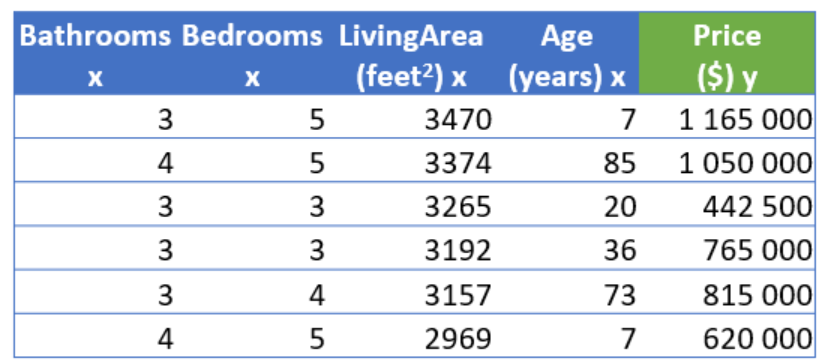

# Task
- Create a regression linearization model from the parameters you selected last exercise
- Standardize the data before processing
- Create the model manually
- Create the model using scikit-learn

# Data loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
data = pd.read_csv ("..\\dataset\\portland_filtered.csv",  sep=';')

# Linear model without using libraries
- Create a linear regression model manually without the help of external libraries
- List its parameters
- List its scores for training and validation data
- Plot a learning history graph
- Visualize the model

MANUAL LINEAR REGRESSION

Parameters:
Bias: 515525.29
bathrooms: 73533.88
bedrooms: -3651.66
livingArea: 77077.63
age: 60524.05

Training R²: 0.6381
Validation R²: 0.4442


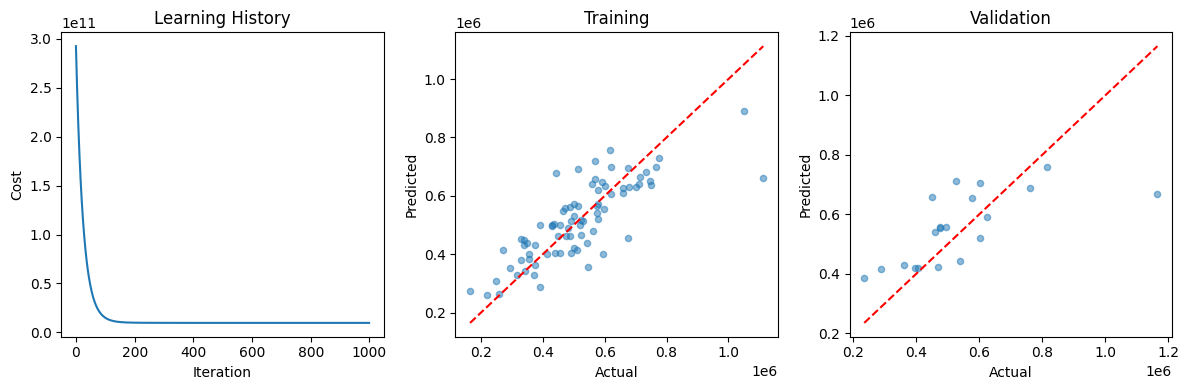

In [23]:
# Select features
X = data[['bathrooms', 'bedrooms', 'livingArea', 'age']].values
Y = data['price'].values

# Split data
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# Standardize
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std, mean, std

X_train_std, mean, std = standardize(X_train)
X_val_std = (X_val - mean) / std

# ============================================
# MANUAL LINEAR REGRESSION
# ============================================

print("MANUAL LINEAR REGRESSION")
print("="*40)

# Initialize parameters
np.random.seed(42)
weights = np.random.randn(X_train_std.shape[1]) * 0.01
bias = 0

# Training
learning_rate = 0.01
iterations = 1000
costs = []

for i in range(iterations):
    # Predict
    y_pred = np.dot(X_train_std, weights) + bias
    
    # Cost
    cost = np.mean((y_pred - Y_train) ** 2)
    costs.append(cost)
    
    # Gradients
    dw = (2 / len(Y_train)) * np.dot(X_train_std.T, (y_pred - Y_train))
    db = (2 / len(Y_train)) * np.sum(y_pred - Y_train)
    
    # Update
    weights -= learning_rate * dw
    bias -= learning_rate * db

# Parameters
print("\nParameters:")
print(f"Bias: {bias:.2f}")
features = ['bathrooms', 'bedrooms', 'livingArea', 'age']
for i, f in enumerate(features):
    print(f"{f}: {weights[i]:.2f}")

# Scores
y_train_pred = np.dot(X_train_std, weights) + bias
y_val_pred = np.dot(X_val_std, weights) + bias

print(f"\nTraining R²: {r2_score(Y_train, y_train_pred):.4f}")
print(f"Validation R²: {r2_score(Y_val, y_val_pred):.4f}")

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(costs)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Learning History')

plt.subplot(1, 3, 2)
plt.scatter(Y_train, y_train_pred, alpha=0.5, s=20)
plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Training')

plt.subplot(1, 3, 3)
plt.scatter(Y_val, y_val_pred, alpha=0.5, s=20)
plt.plot([Y_val.min(), Y_val.max()], [Y_val.min(), Y_val.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Validation')

plt.tight_layout()
plt.show()

# Linear model using scikit-learn
- Create a linear regression model manually without the help of external libraries
- List its parameters
- List its scores for training and validation data
- Plot a learning history graph
- Visualize the model


SCIKIT-LEARN LINEAR REGRESSION

Parameters:
Bias: 516500.31
bathrooms: 74741.78
bedrooms: 974.93
livingArea: 74162.33
age: 60749.69

Training R²: 0.6274
Validation R²: 0.7310


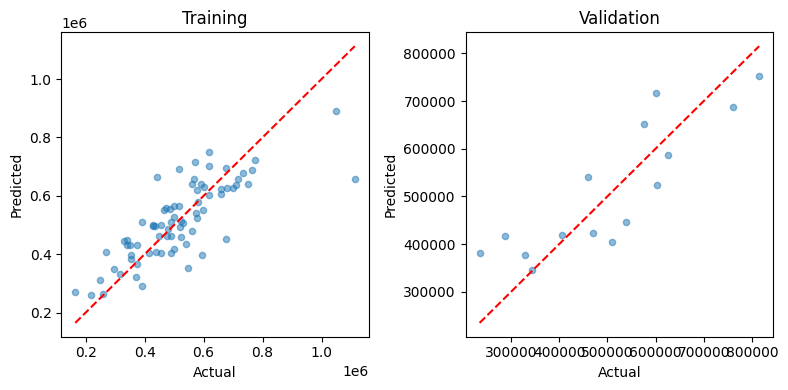

In [22]:
print("\n" + "="*40)
print("SCIKIT-LEARN LINEAR REGRESSION")
print("="*40)

scaler = StandardScaler()
X_train_sklearn = scaler.fit_transform(X_train)
X_val_sklearn = scaler.transform(X_val)

model = LinearRegression()
model.fit(X_train_sklearn, Y_train)

print("\nParameters:")
print(f"Bias: {model.intercept_:.2f}")
for i, f in enumerate(features):
    print(f"{f}: {model.coef_[i]:.2f}")

y_train_pred_sk = model.predict(X_train_sklearn)
y_val_pred_sk = model.predict(X_val_sklearn)

print(f"\nTraining R²: {model.score(X_train_sklearn, Y_train):.4f}")
print(f"Validation R²: {model.score(X_val_sklearn, Y_val):.4f}")

# Plot
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.scatter(Y_train, y_train_pred_sk, alpha=0.5, s=20)
plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Training')

plt.subplot(1, 2, 2)
plt.scatter(Y_val, y_val_pred_sk, alpha=0.5, s=20)
plt.plot([Y_val.min(), Y_val.max()], [Y_val.min(), Y_val.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Validation')

plt.tight_layout()
plt.show()